In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

REGION_COLORS = {
    'Pacific' : '#2980B9',
    'Atlantic': '#27AE60',
    'Interior': '#F39C12',
    'Gulf'    : '#8E44AD'
}

DIVISION_COLORS = {
    'Chocolate': '#27AE60',
    'Sugar'    : '#2980B9',
    'Other'    : '#F39C12'
}

In [2]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter']    = df['Order Date'].dt.quarter

total_revenue      = df['Sales'].sum()
total_profit       = df['Gross Profit'].sum()
company_avg_margin = (total_profit / total_revenue * 100)

print(f"Data loaded: {df.shape[0]} rows")
print(f"Company Avg Margin: {company_avg_margin:.2f}%")

Data loaded: 6013 rows
Company Avg Margin: 65.96%


### Prepare Regional Summary

In [3]:
region_summary = df.groupby('Region').agg(
    Total_Revenue = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum'),
    Total_Cost    = ('Cost', 'sum'),
    Total_Units   = ('Units', 'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Avg_Margin    = ('Gross_Margin_%', 'mean')
).round(2).reset_index()

region_summary['Revenue_Share_%'] = (
    region_summary['Total_Revenue'] / total_revenue * 100
).round(2)

region_summary['Profit_Share_%'] = (
    region_summary['Total_Profit'] / total_profit * 100
).round(2)

region_summary['Margin_vs_Company'] = (
    region_summary['Avg_Margin'] - company_avg_margin
).round(2)

region_summary = region_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

print(region_summary[['Region', 'Total_Revenue', 'Total_Profit',
                       'Avg_Margin', 'Revenue_Share_%', 'Profit_Share_%']].to_string(index=False))

  Region  Total_Revenue  Total_Profit  Avg_Margin  Revenue_Share_%  Profit_Share_%
 Pacific       27560.35      18122.34       66.49            32.88           32.78
Atlantic       24237.06      15901.34       66.36            28.91           28.76
Interior       19343.79      12867.99       67.11            23.08           23.27
    Gulf       12686.23       8399.70       66.53            15.13           15.19


### Chart 25: Revenue by Region

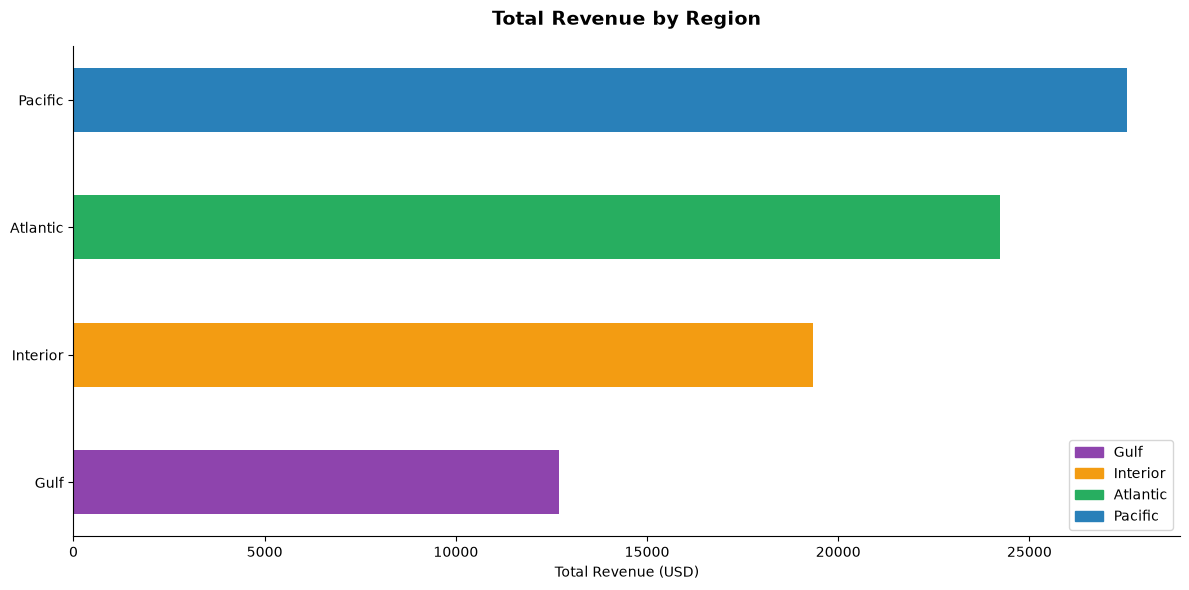

Chart 25 saved


In [4]:
sorted_region = region_summary.sort_values('Total_Revenue', ascending=True)
colors = [REGION_COLORS[r] for r in sorted_region['Region']]

fig, ax = plt.subplots()

ax.barh(sorted_region['Region'], sorted_region['Total_Revenue'],
        color=colors, height=0.5)

ax.set_title('Total Revenue by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (USD)')
ax.set_ylabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=REGION_COLORS[r], label=r)
    for r in sorted_region['Region']
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/25_region_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 25 saved")

### Chart 26: Profit by Region

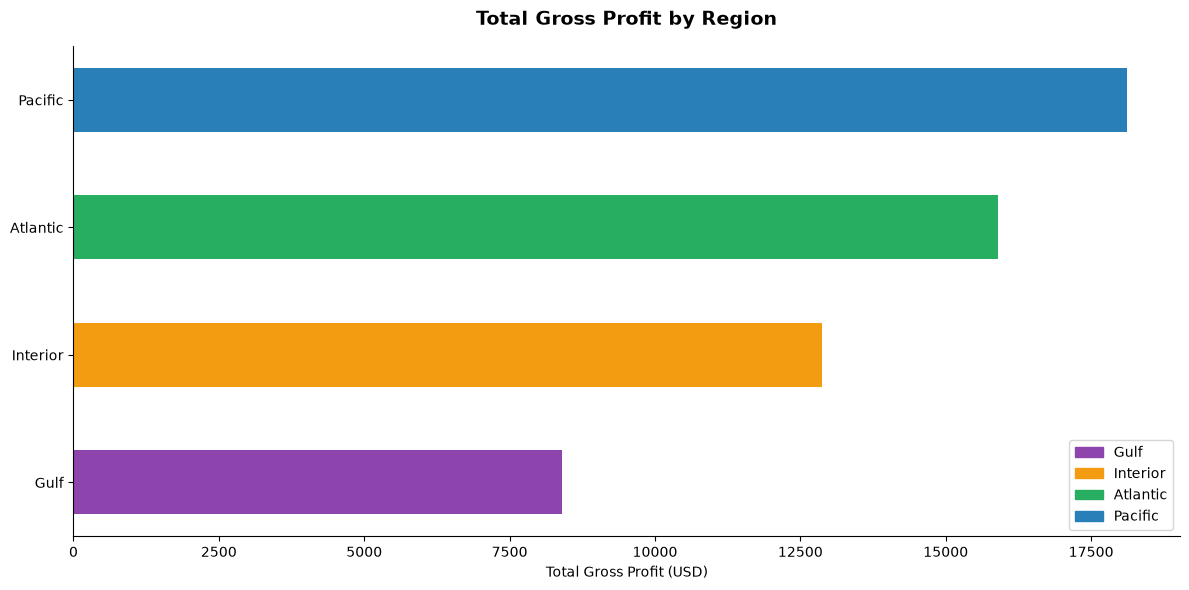

Chart 26 saved


In [5]:
sorted_region = region_summary.sort_values('Total_Profit', ascending=True)
colors = [REGION_COLORS[r] for r in sorted_region['Region']]

fig, ax = plt.subplots()

ax.barh(sorted_region['Region'], sorted_region['Total_Profit'],
        color=colors, height=0.5)

ax.set_title('Total Gross Profit by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Gross Profit (USD)')
ax.set_ylabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=REGION_COLORS[r], label=r)
    for r in sorted_region['Region']
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/26_region_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 26 saved")

### Chart 27: Margin by Region vs Company Average

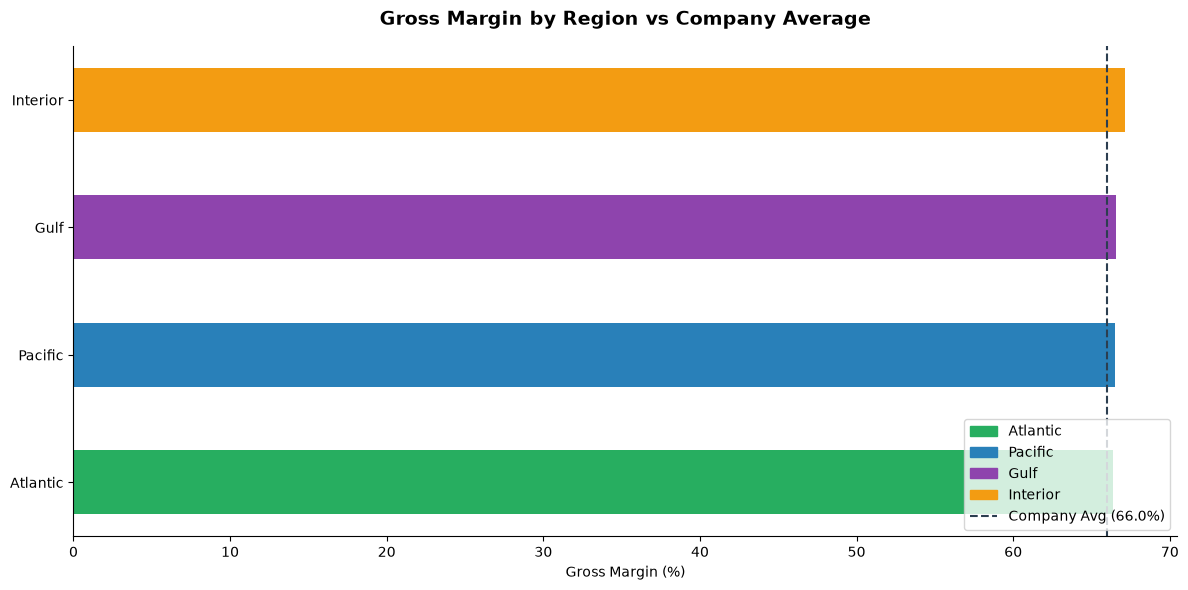

Chart 27 saved


In [6]:
sorted_region = region_summary.sort_values('Avg_Margin', ascending=True)
colors = [REGION_COLORS[r] for r in sorted_region['Region']]

fig, ax = plt.subplots()

ax.barh(sorted_region['Region'], sorted_region['Avg_Margin'],
        color=colors, height=0.5)

ax.axvline(x=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Gross Margin by Region vs Company Average',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gross Margin (%)')
ax.set_ylabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=REGION_COLORS[r], label=r)
    for r in sorted_region['Region']
] + [
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg ({company_avg_margin:.1f}%)')
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/27_region_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 27 saved")

### Prepare Region × Division Heatmap

In [7]:
region_div = df.groupby(['Region', 'Division'])['Gross Profit']\
               .sum().reset_index()

heatmap_pivot = region_div.pivot(
    index='Region',
    columns='Division',
    values='Gross Profit'
).fillna(0).round(2)

# Sort by total profit
heatmap_pivot['Total'] = heatmap_pivot.sum(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('Total', ascending=False)
heatmap_pivot = heatmap_pivot.drop(columns='Total')

print(heatmap_pivot)

Division  Chocolate   Other  Sugar
Region                            
Pacific    17102.45  932.85  87.04
Atlantic   14904.69  926.60  70.05
Interior   12265.44  565.80  36.75
Gulf        8080.70  273.20  45.80


Chart 28: Region × Division Profit Heatmap

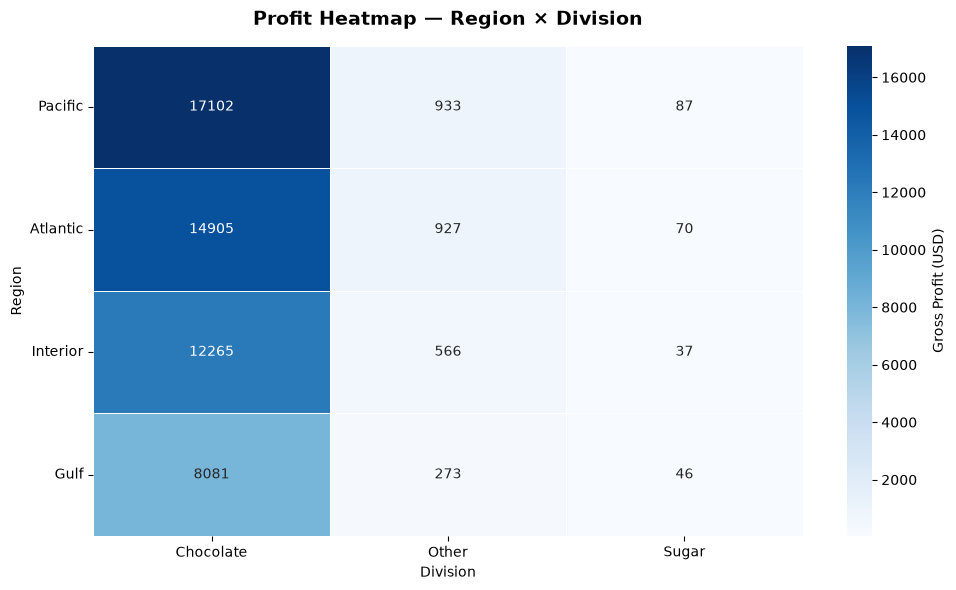

Chart 28 saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Gross Profit (USD)'},
    ax=ax
)

ax.set_title('Profit Heatmap — Region × Division',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Division')
ax.set_ylabel('Region')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/charts/28_region_division_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 28 saved")

### Prepare Quarterly by Region

In [9]:
quarterly_region = df.groupby(['Region', 'Quarter']).agg(
    Total_Revenue = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum'),
    Avg_Margin    = ('Gross_Margin_%', 'mean')
).round(2).reset_index()

quarterly_region['Quarter_Label'] = 'Q' + quarterly_region['Quarter'].astype(str)

print(quarterly_region[['Region', 'Quarter_Label', 
                         'Total_Revenue', 'Total_Profit', 'Avg_Margin']])

      Region Quarter_Label  Total_Revenue  Total_Profit  Avg_Margin
0   Atlantic            Q1        3283.10       2145.48       66.30
1   Atlantic            Q2        5200.36       3422.70       66.42
2   Atlantic            Q3        6579.72       4320.51       66.52
3   Atlantic            Q4        9173.88       6012.65       66.23
4       Gulf            Q1        1669.25       1128.09       67.37
5       Gulf            Q2        3214.62       2135.36       66.30
6       Gulf            Q3        3325.72       2151.36       65.93
7       Gulf            Q4        4476.64       2984.89       66.83
8   Interior            Q1        2842.37       1891.43       66.98
9   Interior            Q2        3733.24       2514.08       67.11
10  Interior            Q3        5937.69       3897.63       66.94
11  Interior            Q4        6830.49       4564.85       67.29
12   Pacific            Q1        3671.27       2429.74       66.57
13   Pacific            Q2        5544.83       

### Chart 29: Quarterly Revenue Trend by Region

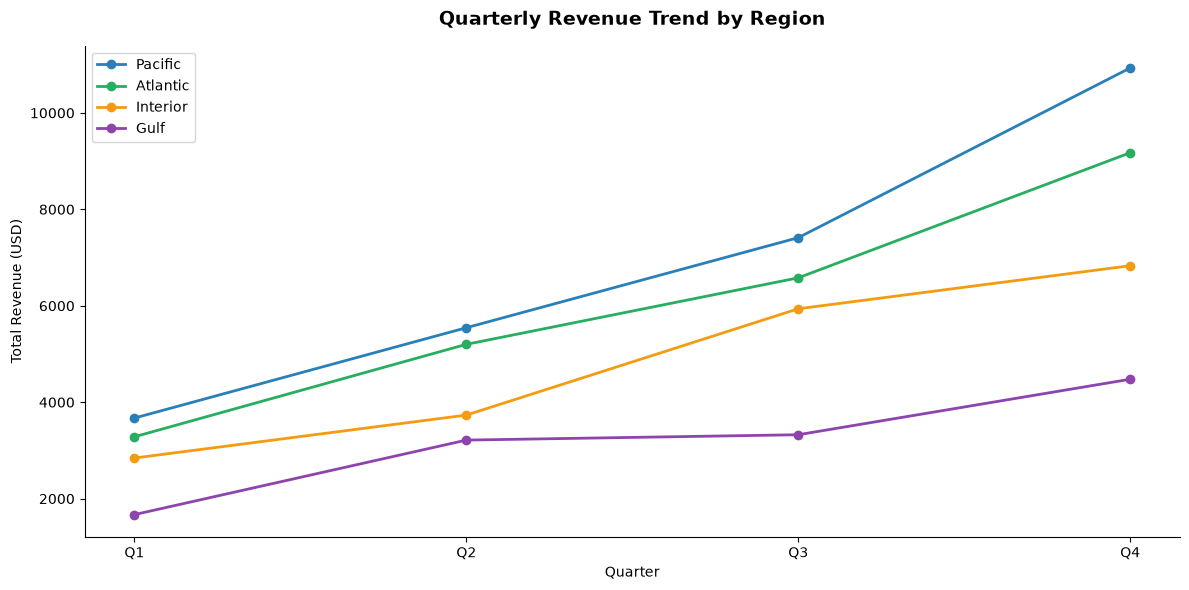

Chart 29 saved


In [10]:
fig, ax = plt.subplots()

for region, color in REGION_COLORS.items():
    subset = quarterly_region[quarterly_region['Region'] == region]
    ax.plot(subset['Quarter_Label'], subset['Total_Revenue'],
            color=color, marker='o', linewidth=2, label=region)

ax.set_title('Quarterly Revenue Trend by Region',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Revenue (USD)')
ax.set_xlabel('Quarter')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/charts/29_region_quarterly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 29 saved")

### Chart 30: Ship Mode Distribution by Region

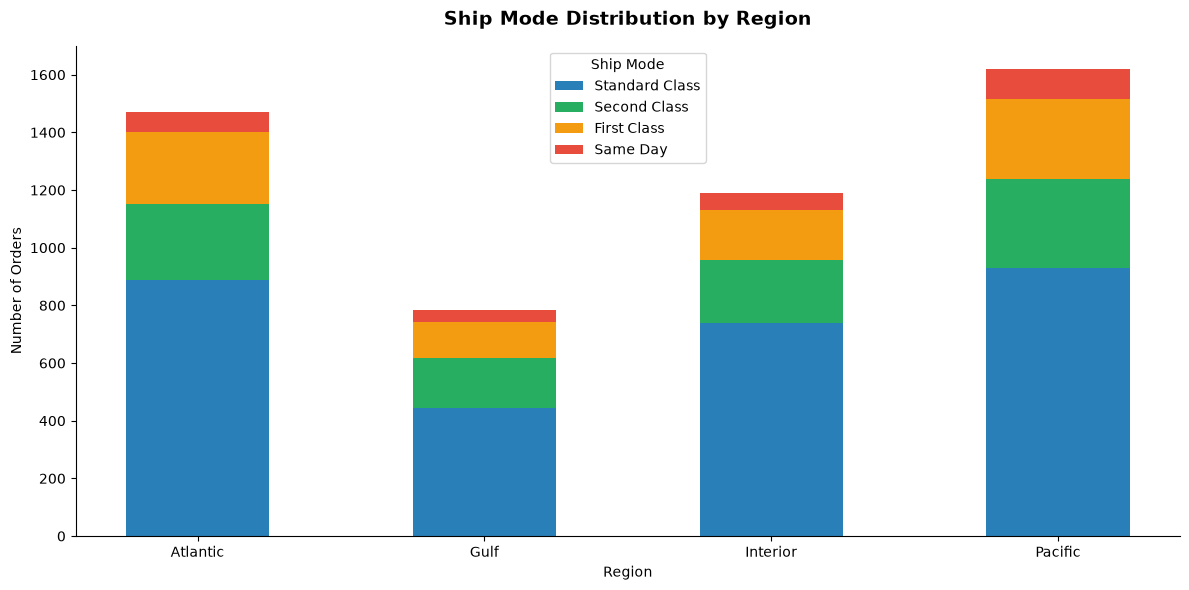

Chart 30 saved


In [11]:
ship_region = df.groupby(['Region', 'Ship Mode'])['Order ID']\
                .nunique().reset_index()
ship_region.columns = ['Region', 'Ship Mode', 'Orders']

ship_pivot = ship_region.pivot(
    index='Region',
    columns='Ship Mode',
    values='Orders'
).fillna(0)

SHIP_COLORS = {
    'Standard Class': '#2980B9',
    'Second Class'  : '#27AE60',
    'First Class'   : '#F39C12',
    'Same Day'      : '#E74C3C'
}

fig, ax = plt.subplots()

bottom = np.zeros(len(ship_pivot))
for ship_mode, color in SHIP_COLORS.items():
    ax.bar(ship_pivot.index, ship_pivot[ship_mode],
           bottom=bottom, color=color, label=ship_mode, width=0.5)
    bottom += ship_pivot[ship_mode].values

ax.set_title('Ship Mode Distribution by Region',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Orders')
ax.set_xlabel('Region')
ax.legend(title='Ship Mode', loc='upper center')

plt.tight_layout()
plt.savefig('../outputs/charts/30_region_ship_mode_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 30 saved")